### Artificial Intelligence 601.464 Project #8: Game Agents

#### Before You Begin...
00. We're using a Jupyter Notebook environment (tutorial available here: https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html),
01. Read the entire notebook before beginning your work, and
02.  Check the submission deadline on Gradescope.


#### General Directions for this Assignment
01. Functions should do only one thing,
02. Keep functions to 20 lines or less (empty lines are fine, there's leeway, but don't blatantly ignore this),
03. Add docstring to all functions,


#### Before You Submit...
00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.

### The Problem

For this assignment we will solve difficult game states using any AI technique we learned in this course!
Choose some possible games we can simulate and solve:

We are dividing these games by their intractibility P/NP (P can be solved in polynomial time, NP cannot be solved in polynomial time). With the tools that we've learned in this class we are able to find heuristics that can help solve some of these hard problems in polynomial time!

<span style="color:red">Choose *ONE* game (either P or NP)</span>.


#### P Games (*Only* these options):
These are simple games that have polytime solutions, *make your own game simulation*, and use one of the techniques taught in class.
- Wordle
- Connections
- Crossword Minis
- Strands
- Ultimate Tic-Tac-Toe

#### NP Games (*Any* game, including these!) 
*+5 Extra Credit*

Since these are complex games to simulate we are allowing you to import libraries that help you simulate a game. We have provided some libraries that may help, but you can also use your own! Like P games, use one of the techniques taught in class to solve these games!
- [Sudoku](https://github.com/jeffsieu/py-sudoku/tree/master)
- [Flow](https://github.com/amoralesc/flow/tree/main) (Hard)
- [Solitaire](https://github.com/jamesboehmer/pytience/tree/master)
- [Blackjack](https://github.com/EvanA4/blackjack-api)
- [Poker](https://github.com/uoftcprg/pokerkit) (Hard)
- [Minesweeper](https://github.com/duguyue100/minesweeper/tree/master)
- [Dominoes](https://dominoes.readthedocs.io/en/latest/)
- [Super Mario Bros.](https://github.com/Kautenja/gym-super-mario-bros) 
- Any NP game of your choosing! (Must be NP, provide a link to a website showing this game is NP, NP-Hard, NP-Complete)


These games can all be done using various different tools: some are better suited than others, but it's fun to try different combinations to see what works best.

#### Some Techniques We have learned in this class:
- Classical Search (DFS, BFS, A*, Beam Search)
- Minimax / Minimax+aB
- Multiagent Systems
- Game Theory / Nash Equilibria
- Constraint Satisfaction (MRV, LCV, Backtracking, Backjumping)
- Genetic Algorithms
- Decision Trees and Random Forests
- Reinforcement Learning
- Unsupervised Learning / Clustering Algorithms
- Neural Networks
- Convolutional Neural Networks
- Natural Language Processing and LLMs
- Any other concept we reviewed in class!

## Imports
What game are you simulating?
What tech stack are you using? 
- HuggingFace, pytorch, sk-learn, gymnasium, pygame, or simple built-in libraries. 

Import them here!

I'll be simulating Blackjack using Gymnasium.

In [1]:
# I'm keeping this commented and installing it elsewhere because my ipykernel behaves oddly when I don't, and this makes it easier for me
#!pip install gymnasium


In [2]:
# Imports go here.
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import random
from collections import defaultdict

%matplotlib inline

## Data
What kind of data are we working with? 
- Historical movesets from games? 
- The past 1000 published games? 
- The map for a world?
- Oxford Dictionary collection of words? 

Import your data here if you have any!

In [3]:
# No data for Blackjack!

## Implementation
Design your model that will solve your game. Choose any of the techniques listed!

In [4]:
# Sets up environment
env = gym.make("Blackjack-v1", sab=True)

In [5]:
def draw_card():
    """
    Returns a random card value.
    Returns:
        - int: random value between 1 and 13, with values > 10 capped at 10
    """
    return min(random.randint(1, 13), 10)

In [6]:
def simulate_dealer(dealer_sum):
    """
    Simulates dealer play (hits until >= 17).
    Args:
        - dealer_sum (int): the position of the dealer at the start of the turn
    Returns:
        - dealer_sum (int): the position of the dealer after the turn
    """
    while dealer_sum < 17:
        dealer_sum += draw_card()
    return dealer_sum

In [7]:
def evaluate_stick(player_sum, dealer_card, simulations=100):
    """
    Monte Carlo estimate of sticking value.
    Args:
        - player_sum (int): current points of the agent
        - dealer_card (int): value of the dealer's card
        - simulations (int): number of simulations to run
    Returns:
        - float: win rate in stick simulations
    """
    wins = 0

    for _ in range(simulations):
        dealer_sum = dealer_card + draw_card()
        dealer_sum = simulate_dealer(dealer_sum)

        if dealer_sum > 21 or player_sum > dealer_sum:
            wins += 1
        elif player_sum < dealer_sum:
            wins -= 1

    return wins / simulations

In [8]:
def evaluate_hit(player_sum, dealer_card, simulations=100):
    """
    Monte Carlo estimate of hitting value.
    Args:
        - player_sum (int): current points of the agent
        - dealer_card (int): value of the dealer's card
        - simulations (int): number of simulations to run
    Returns:
        - float: win rate in hit simulations
    """
    total = 0

    for _ in range(simulations):
        new_sum = player_sum + draw_card()

        if new_sum > 21:
            total -= 1
        else:
            total += evaluate_stick(new_sum, dealer_card, simulations=10)

    return total / simulations

In [9]:
def policy(state):
    """
    Chooses action that maximizes utility based on simulations.
    Args:
        - state (tuple): current position of the player
    Returns:
        - int: whether the player should hit
    """
    player_sum, dealer_card, usable_ace = state

    hit_value = evaluate_hit(player_sum, dealer_card)
    stick_value = evaluate_stick(player_sum, dealer_card)

    return 1 if hit_value > stick_value else 0

In [10]:
def random_policy(state):
    """
    Chooses a random action (used in benchmarking my policy).
    Args:
        - state (tuple): current position of the player
    Returns:
        - int: random action
    """
    return env.action_space.sample()

In [11]:
def run_policy(policy_fn, episodes=10000):
    """
    Runs a policy for a number of episodes and returns rewards.
    Args:
        - policy_fn (func): the policy to run
        - episodes (int): number of simulations
    Returns:
        - rewards (list): the list of games played and their results
    """
    rewards = []
    first_ep = 0
    reward_sum_inc = 0

    # Iterates through every game
    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        # Hits until done
        while not done:
            action = policy_fn(state)
            state, reward, done, _, _ = env.step(action)
            total_reward += reward

        # Processes results
        rewards.append(total_reward)
        reward_sum_inc += total_reward

        if (episode + 1) % 500 == 0:
            print(f"{first_ep}-{episode}: Reward={reward_sum_inc}")
            first_ep = episode + 1
            reward_sum_inc = 0



    return rewards

In [12]:
# Runs both policies
print("---BEST RESPONSE POLICY---")
model_rewards = run_policy(policy)

print()

print("---RANDOM POLICY---")
random_rewards = run_policy(random_policy)

---BEST RESPONSE POLICY---
0-499: Reward=-32.0
500-999: Reward=-13.0
1000-1499: Reward=-6.0
1500-1999: Reward=-40.0
2000-2499: Reward=-19.0
2500-2999: Reward=-54.0
3000-3499: Reward=-65.0
3500-3999: Reward=-25.0
4000-4499: Reward=-38.0
4500-4999: Reward=-13.0
5000-5499: Reward=-4.0
5500-5999: Reward=-62.0
6000-6499: Reward=-2.0
6500-6999: Reward=-64.0
7000-7499: Reward=-55.0
7500-7999: Reward=-36.0
8000-8499: Reward=-20.0
8500-8999: Reward=-26.0
9000-9499: Reward=-46.0
9500-9999: Reward=-44.0

---RANDOM POLICY---
0-499: Reward=-168.0
500-999: Reward=-195.0
1000-1499: Reward=-195.0
1500-1999: Reward=-171.0
2000-2499: Reward=-187.0
2500-2999: Reward=-195.0
3000-3499: Reward=-230.0
3500-3999: Reward=-186.0
4000-4499: Reward=-199.0
4500-4999: Reward=-201.0
5000-5499: Reward=-185.0
5500-5999: Reward=-223.0
6000-6499: Reward=-212.0
6500-6999: Reward=-182.0
7000-7499: Reward=-226.0
7500-7999: Reward=-185.0
8000-8499: Reward=-207.0
8500-8999: Reward=-168.0
9000-9499: Reward=-190.0
9500-9999: R

In [13]:
# Computes win rates
model_win_rate = np.mean(np.array(model_rewards) > 0)
random_win_rate = np.mean(np.array(random_rewards) > 0)

In [14]:
# Prints results
print("Best Response Model Win Rate:", model_win_rate)
print("Random Win Rate:", random_win_rate)

Best Response Model Win Rate: 0.427
Random Win Rate: 0.2839


In [15]:
def cumulative_win_rate(rewards):
    """
    Computes cumulative win rate.
    Args:
        - rewards (list): A list of results of the game
    Returns
        - np.array: how the model is evolving to win
    
    """
    wins = np.array(rewards) > 0
    return np.cumsum(wins) / np.arange(1, len(wins) + 1)

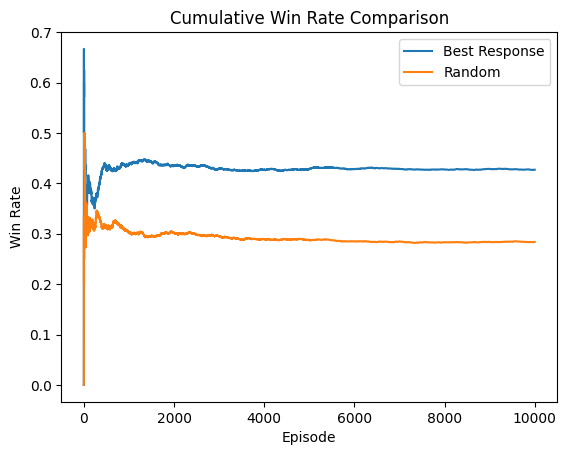

In [16]:
# Plots cumulative win rates
plt.plot(cumulative_win_rate(model_rewards), label="Best Response")
plt.plot(cumulative_win_rate(random_rewards), label="Random")
plt.title("Cumulative Win Rate Comparison")
plt.xlabel("Episode")
plt.ylabel("Win Rate")
plt.legend()
plt.show()

## Evaluation
**Run your game and model 100 times** (or by how much your data size permits), how many times does your model succeed? 

What is your model's success rate?

If you trained your model, show your loss and accuracy plots here:

In [17]:
test_rewards = []

# Runs 100 simulations
for _ in range(100):
    state, _ = env.reset()
    done = False
    total_reward = 0

    # Uses my best response policy
    while not done:
        action = policy(state)
        state, reward, done, _, _ = env.step(action)
        total_reward += reward

    test_rewards.append(total_reward)

print("Test Win Rate:", np.mean(np.array(test_rewards) > 0))

Test Win Rate: 0.46


## Discussion
Did your model perform as expected? 

What issues did you encounter along the way?

Was the game you chose too complex to model under this timeframe?

Talk about what you learned! 

My model pretty much performed as expected. The win rate was only 46% on the test set, which would be pretty rough in classification tasks, like most of what I've been working on lately. However, in comparison with the random model, which chooses to Hit or Stick arbitrarily, this model performs relatively at a high level and does work as a formidable player.

For the graph, I decided to use the cumulative sum of wins, since it can show how the model evolves as it undergoes the training loop. The graph is rather interesting, since there is a large spike in cumulative win rate in the beginning, before it evens out. This indicates that there were a large number of wins in the beginning, before the win rate quickly stabilized. This makes sense, since the spike appeared within the first very few games, where so much as 5 more wins than losses would cause a high cumulative win rate. The graph quickly stabilized, which indicates to me that I didn't need all 10000 runs for the simulation loop; I could've run it as little as 4000 times and gotten roughly the same results.

One issue I encountered was figuring out how to evaluate my model. In recent homeworks, it's been relatively easy to just take the accuracy against random chance and then determine if the results perform better than chance. However, this is less simple. I decided to use a random policy, which provided a good benchmark to work off of.

I also had some trouble with simulations. I initially tried something far too complicated, where I modeled an actual deck of cards with the accurate proportions of each value, but this was overly complicated for the limited repeated simulations, which were just running a couple hits each, not nearly enough for the deck running out to become a problem. This is how I decided on my very simple draw_card function, which worked vry well.

I think Blackjack was a solid level of complexity for this time frame. I feel like I was really able to use what I learned about game theory to create a game agent that modeled many results and went with the correct one based on expected value. I think I could've done a game like Poker, but that seems incredibly complicated and I would be worried about modeling all of the different values of hands, as opposed to just summing the value of the cards like in Blackjack. I think this allowed me to use what I've learned without getting bogged down in rules of the game.

Overall, this project taught me a lot about modeling. I modelled Blackjack as a stochastic game and computed the best next action based on a game theoretic best response policy. It was similar to our work with Nash equilibria, since my best-response policy functionally computed the argmax of the set of actions. It reminded me a lot of the stag hunt game from Project 2, but it was more complicated and more familiar to me, as someone who likes card games. It was a cool way to showcase what I've learned.

## Before You Submit...

00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.